In [1]:
import pandas as pd

In [2]:
data=pd.read_csv("Admission_Predict.csv")

In [3]:
data

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [4]:
import numpy as np
data["Admitted"]=np.where(data["Chance of Admit"]>0.8,1,0)

In [7]:
data=data.drop(["Chance of Admit"],axis=1)
data

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted
0,1,337,118,4,4.5,4.5,9.65,1,1
1,2,324,107,4,4.0,4.5,8.87,1,0
2,3,316,104,3,3.0,3.5,8.00,1,0
3,4,322,110,3,3.5,2.5,8.67,1,0
4,5,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,1
396,397,325,107,3,3.0,3.5,9.11,1,1
397,398,330,116,4,5.0,4.5,9.45,1,1
398,399,312,103,3,3.5,4.0,8.78,0,0


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,confusion_matrix,classification_report

In [19]:
x=data.drop(["Admitted"],axis=1)
y=data["Admitted"]

In [20]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [21]:
model=DecisionTreeClassifier()

In [22]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [23]:
y_pred=model.predict(x_test)

In [24]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.93      0.96      0.94        68\n           1       0.90      0.84      0.87        32\n\n    accuracy                           0.92       100\n   macro avg       0.91      0.90      0.91       100\nweighted avg       0.92      0.92      0.92       100\n'

In [25]:
print("Accuracy",accuracy_score(y_test,y_pred))

Accuracy 0.92


[Text(0.4166666666666667, 0.9444444444444444, 'CGPA <= 8.93\ngini = 0.406\nsamples = 300\nvalue = [215, 85]\nclass = Admitted'),
 Text(0.18518518518518517, 0.8333333333333334, 'CGPA <= 8.63\ngini = 0.083\nsamples = 208\nvalue = [199, 9]\nclass = Admitted'),
 Text(0.30092592592592593, 0.8888888888888888, 'True  '),
 Text(0.1111111111111111, 0.7222222222222222, 'LOR <= 1.75\ngini = 0.013\nsamples = 148\nvalue = [147, 1]\nclass = Admitted'),
 Text(0.07407407407407407, 0.6111111111111112, 'GRE Score <= 316.5\ngini = 0.278\nsamples = 6\nvalue = [5, 1]\nclass = Admitted'),
 Text(0.037037037037037035, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = Admitted'),
 Text(0.1111111111111111, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = Not Adimitted'),
 Text(0.14814814814814814, 0.6111111111111112, 'gini = 0.0\nsamples = 142\nvalue = [142, 0]\nclass = Admitted'),
 Text(0.25925925925925924, 0.7222222222222222, 'Research <= 0.5\ngini = 0.231\nsamples = 60\nvalue = [52, 8]\nclass = Ad

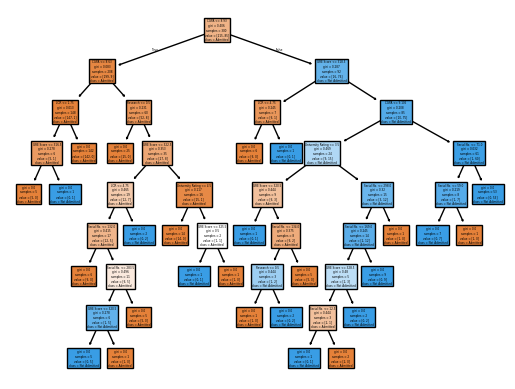

In [32]:
plot_tree(model,filled=True,feature_names=x.columns,class_names=["Admitted","Not Adimitted"])